# 06. Merge assay metadata with compound counts

This script merges two sources:
- `summary_data.csv`: compound and substance counts per AID
- `filtered_description_with_organisms_v2_REBUILT.csv`: metadata including pathogen and ChEMBL ID

Output: `summary_bioassays.csv`

## 00. Setup

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define paths
PROJECT_ROOT = Path("/Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks")
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

## 01. Load input files

In [3]:
summary_data = pd.read_csv(DATA_PROCESSED / "summary_data.csv")
summary_data = summary_data.sort_values('AID', ascending = True ).reset_index(drop = True)
summary_data.head(5)

,AID,substances_count,compound_count
0,365,206,205
1,375,10011,10009
2,448,64651,63782
3,547,1280,1274
4,555,65267,65241


In [4]:
summary_description = pd.read_csv(DATA_PROCESSED / "filtered_description_with_organisms_v2_REBUILT.csv")
summary_description = summary_description.sort_values('AID', ascending = True ).reset_index(drop = True)
summary_description

,AID,Pathogen,ChEMBLid,TaxID_AssayTarget,TaxID_XRef,TaxID_ResultType,TaxIDs_All,AssayOrganism
0,365,Escherichia coli,NaN,[],['562'],[],['562'],[]
1,375,Mycobacterium tuberculosis,NaN,[],['1773'],[],['1773'],"['Mycobacterium tuberculosis', 'MYCOBACTERIUM ..."
2,448,Schistosoma mansoni,NaN,[],['6183'],[],['6183'],[]
3,547,Escherichia coli,NaN,[],['83333'],[],['83333'],"['molecular chaperone DnaK (dnaK).', 'molecula..."
4,555,Streptococcus pneumoniae,NaN,[],['373153'],[],['373153'],[]
...,...,...,...,...,...,...,...,...
129922,2061452,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129923,2061453,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129924,2061454,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...
129925,2061455,Pseudomonas aeruginosa,NaN,[],[],[],[],['INHIBITORS OF PSEUDOMONAS AERUGINOSA VIRULEN...


In [5]:
summary_description["Has_ChEMBL"] = summary_description["ChEMBLid"].notna()

summary_chembl = (
    summary_description[summary_description["Has_ChEMBL"]]
    .groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="AIDs_with_ChEMBL")
    .sort_values("AIDs_with_ChEMBL", ascending=False)
)

summary_chembl

,Pathogen,AIDs_with_ChEMBL
13,Staphylococcus aureus,33750
5,Escherichia coli,24498
11,Pseudomonas aeruginosa,14456
2,Candida albicans,13106
8,Mycobacterium tuberculosis,12598
10,Plasmodium falciparum,9997
7,Klebsiella pneumoniae,5800
14,Streptococcus pneumoniae,4356
0,Acinetobacter baumannii,3576
3,Enterobacter,2509


## 02. Merge on AID

In [6]:
summary_bioassays = summary_data.merge(
    summary_description[["AID", "Pathogen", "ChEMBLid"]],
    on="AID",
    how="left"
)

summary_bioassays = summary_bioassays[["Pathogen", "AID", "compound_count", "substances_count", "ChEMBLid"]]

summary_bioassays = summary_bioassays.rename(columns={
    "AID": "PubChem_AID",
    "substances_count": "PubChem_substances",
    "compound_count": "PubChem_compounds",
    "ChEMBLid": "ChEMBL_ID"
})

summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID
0,Escherichia coli,365,205,206,NaN
1,Mycobacterium tuberculosis,375,10009,10011,NaN
2,Schistosoma mansoni,448,63782,64651,NaN
3,Escherichia coli,547,1274,1280,NaN
4,Streptococcus pneumoniae,555,65241,65267,NaN
...,...,...,...,...,...
129880,Pseudomonas aeruginosa,2061452,43,43,NaN
129881,Pseudomonas aeruginosa,2061453,4,4,NaN
129882,Pseudomonas aeruginosa,2061454,4,4,NaN
129883,Pseudomonas aeruginosa,2061455,4,4,NaN


## 03. Save output

In [7]:
PUBCHEM = DATA_PROCESSED / "PubChem_bioassays"
PUBCHEM.mkdir(parents=True, exist_ok=True)

summary_bioassays.to_csv(PUBCHEM / "summary_bioassays.csv", index=False)

## 04. Merge with ChEMBL dataframes

Some assays have more than one pathogen detected, because we have searched for taxid and assay organism.

In [8]:
summary_bioassays["Pathogen"].unique()

array(['Escherichia coli', 'Mycobacterium tuberculosis',
       'Schistosoma mansoni', 'Streptococcus pneumoniae',
       'Staphylococcus aureus', 'Pseudomonas aeruginosa',
       'Candida albicans', 'Escherichia coli, Mycobacterium tuberculosis',
       'Plasmodium falciparum', 'Enterobacter, Escherichia coli',
       'Acinetobacter baumannii', 'Enterobacter', 'Campylobacter',
       'Klebsiella pneumoniae', 'Helicobacter pylori',
       'Enterococcus faecium', 'Neisseria gonorrhoeae',
       'Escherichia coli, Pseudomonas aeruginosa',
       'Escherichia coli, Helicobacter pylori',
       'Acinetobacter baumannii, Candida albicans, Escherichia coli, Mycobacterium tuberculosis, Staphylococcus aureus'],
      dtype=object)

In [9]:
# Convert Pathogen column to string, just in case
summary_bioassays["Pathogen"] = summary_bioassays["Pathogen"].astype(str)

# Convert to list (split by comma + space)
summary_bioassays["Pathogen_list"] = summary_bioassays["Pathogen"].str.split(", ")

# Find rows with >1 pathogen
multi_pathogen_rows = summary_bioassays[summary_bioassays["Pathogen_list"].apply(len) > 1].copy()

# Create a clean string version for display or export (optional)
multi_pathogen_rows["Pathogen_str"] = multi_pathogen_rows["Pathogen_list"].apply(lambda x: ", ".join(x))

# Show count and preview
print(f"Multi-pathogen assays: {len(multi_pathogen_rows)}")
multi_pathogen_rows[["PubChem_AID", "Pathogen_str"]]

Multi-pathogen assays: 22


,PubChem_AID,Pathogen_str
23,1376,"Escherichia coli, Mycobacterium tuberculosis"
27,1494,"Enterobacter, Escherichia coli"
29224,463099,"Escherichia coli, Pseudomonas aeruginosa"
29225,463100,"Escherichia coli, Pseudomonas aeruginosa"
30596,488955,"Escherichia coli, Helicobacter pylori"
30825,492957,"Escherichia coli, Helicobacter pylori"
55902,623916,"Escherichia coli, Helicobacter pylori"
55903,623917,"Escherichia coli, Helicobacter pylori"
55904,623918,"Escherichia coli, Helicobacter pylori"
55905,623919,"Escherichia coli, Helicobacter pylori"


In [10]:
# Get list of AIDs with multiple pathogens
aids_to_exclude = set(multi_pathogen_rows["PubChem_AID"])

# Filter df to exclude those AIDs
summary_bioassays = summary_bioassays[~summary_bioassays["PubChem_AID"].isin(aids_to_exclude)]
summary_bioassays = summary_bioassays.drop(columns = ['Pathogen_list'])
summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID
0,Escherichia coli,365,205,206,NaN
1,Mycobacterium tuberculosis,375,10009,10011,NaN
2,Schistosoma mansoni,448,63782,64651,NaN
3,Escherichia coli,547,1274,1280,NaN
4,Streptococcus pneumoniae,555,65241,65267,NaN
...,...,...,...,...,...
129880,Pseudomonas aeruginosa,2061452,43,43,NaN
129881,Pseudomonas aeruginosa,2061453,4,4,NaN
129882,Pseudomonas aeruginosa,2061454,4,4,NaN
129883,Pseudomonas aeruginosa,2061455,4,4,NaN


In [11]:
# Prepare list of pathogen files (from Arnau's ChEMBL project)
pathogen_dir = DATA_PROCESSED / "ChEMBL_bioassays"
pathogen_files = list(pathogen_dir.glob("*_ChEMBL_data.csv"))

# Initialize empty list to collect all [assay_id, cpds] rows
cpds_rows = []

# Process each pathogen file
for file in pathogen_files:
    df = pd.read_csv(file, low_memory=False)
    if "assay_chembl_id" in df.columns and "compound_chembl_id" in df.columns:
        tmp = df.groupby("assay_chembl_id")["compound_chembl_id"].nunique().reset_index()
        tmp = tmp.rename(columns={"assay_chembl_id": "ChEMBL_ID", "compound_chembl_id": "ChEMBL_compounds"})
        cpds_rows.append(tmp)

# Concatenate all assay-level compound counts
df_cpds = pd.concat(cpds_rows).drop_duplicates(subset=["ChEMBL_ID"])

# Merge into summary
summary_bioassays = summary_bioassays.merge(df_cpds, on="ChEMBL_ID", how="left")

# Fill missing counts with 0 and convert to integer
summary_bioassays["ChEMBL_compounds"] = summary_bioassays["ChEMBL_compounds"].fillna(0).astype(int)

# Save updated summary
summary_bioassays.to_csv(DATA_PROCESSED / "summary_bioassays_with_chembl_compounds.csv", index=False)

summary_bioassays.head()

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID,ChEMBL_compounds
0,Escherichia coli,365,205,206,NaN,0
1,Mycobacterium tuberculosis,375,10009,10011,NaN,0
2,Schistosoma mansoni,448,63782,64651,NaN,0
3,Escherichia coli,547,1274,1280,NaN,0
4,Streptococcus pneumoniae,555,65241,65267,NaN,0


## 06. Check number of compounds in PubChem vs ChEMBL

In [12]:
# Checking if compounds numbers are equal in PubChem vs ChEMBL

summary_bioassays["same_compound_count"] = (
    summary_bioassays["PubChem_compounds"] == summary_bioassays["ChEMBL_compounds"]
)

summary_bioassays.to_csv(DATA_PROCESSED / "summary_bioassays_with_chembl_compounds.csv", index=False)

In [13]:
summary_bioassays

,Pathogen,PubChem_AID,PubChem_compounds,PubChem_substances,ChEMBL_ID,ChEMBL_compounds,same_compound_count
0,Escherichia coli,365,205,206,NaN,0,False
1,Mycobacterium tuberculosis,375,10009,10011,NaN,0,False
2,Schistosoma mansoni,448,63782,64651,NaN,0,False
3,Escherichia coli,547,1274,1280,NaN,0,False
4,Streptococcus pneumoniae,555,65241,65267,NaN,0,False
...,...,...,...,...,...,...,...
129858,Pseudomonas aeruginosa,2061452,43,43,NaN,0,False
129859,Pseudomonas aeruginosa,2061453,4,4,NaN,0,False
129860,Pseudomonas aeruginosa,2061454,4,4,NaN,0,False
129861,Pseudomonas aeruginosa,2061455,4,4,NaN,0,False


In [14]:
# Group by pathogen
summary_pubchem_chembl = summary_bioassays.groupby("Pathogen").agg(
    PubChem_AIDs=("PubChem_AID", "nunique"),
    ChEMBL_IDs=("ChEMBL_ID", lambda x: x.notna().sum()),
    Matching_Compounds=("same_compound_count", "sum"),
    Total_with_ChEMBL=("same_compound_count", "count")  # Only rows with ChEMBL compound counts
).reset_index()


# Compute percentage of ChEMBL IDs
summary_pubchem_chembl["Percent_ChEMBL_IDs"] = (
    100 * summary_pubchem_chembl["ChEMBL_IDs"] / summary_pubchem_chembl["PubChem_AIDs"]
).round(1)

# Compute percentage of matched compounds (among only those with ChEMBL IDs)
summary_pubchem_chembl["Percent_Matching_Compounds"] = (
    100 * summary_pubchem_chembl["Matching_Compounds"] / summary_pubchem_chembl["Total_with_ChEMBL"]
).round(1)

# Drop intermediate column
summary_pubchem_chembl.drop(columns="Total_with_ChEMBL", inplace=True)

# Reorder columns
summary = summary_pubchem_chembl[
    ["Pathogen", "PubChem_AIDs", "ChEMBL_IDs", "Percent_ChEMBL_IDs", 
     "Matching_Compounds", "Percent_Matching_Compounds"]
]

summary_pubchem_chembl

,Pathogen,PubChem_AIDs,ChEMBL_IDs,Matching_Compounds,Percent_ChEMBL_IDs,Percent_Matching_Compounds
0,Acinetobacter baumannii,3580,3575,3286,99.9,91.8
1,Campylobacter,342,333,331,97.4,96.8
2,Candida albicans,13198,13105,11931,99.3,90.4
3,Enterobacter,2509,2509,1769,100.0,70.5
4,Enterococcus faecium,1995,1995,1950,100.0,97.7
5,Escherichia coli,24588,24497,24029,99.6,97.7
6,Helicobacter pylori,920,906,891,98.5,96.8
7,Klebsiella pneumoniae,5799,5799,5605,100.0,96.7
8,Mycobacterium tuberculosis,12735,12598,11816,98.9,92.8
9,Neisseria gonorrhoeae,500,500,498,100.0,99.6


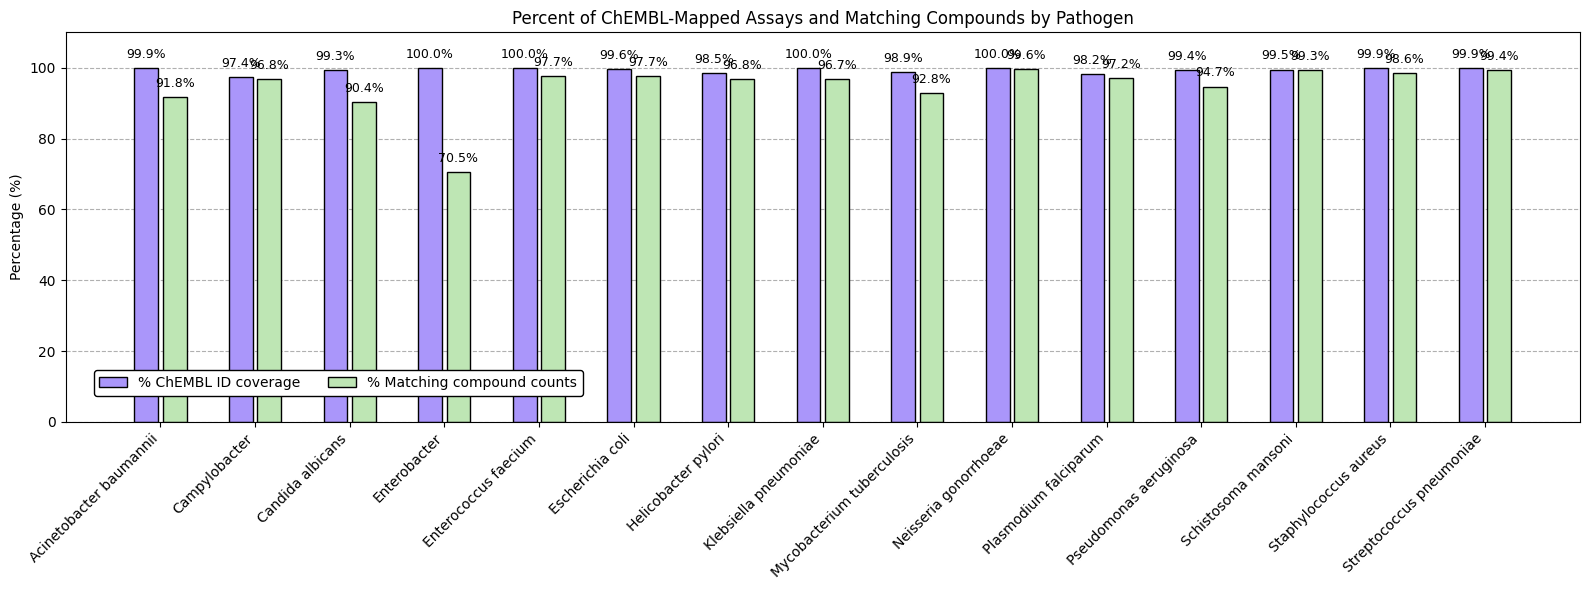

In [ ]:
# Data
summary = summary_pubchem_chembl.copy()
labels = summary["Pathogen"].values
percent_chembl = summary["Percent_ChEMBL_IDs"].values
percent_matching = summary["Percent_Matching_Compounds"].values

N = len(labels)
x = np.arange(N)

# ⏩ Adjust spacing: smaller bar width + larger offset
bar_width = 0.25
bar_spacing = 0.15  # controls the separation inside each group

# Colors
color_chembl = "#AA96FA"    # Purple
color_match  = "#BEE6B4"    # Green

# Plot
plt.figure(figsize=(16, 6))

# 1. Bar: Percent_ChEMBL_IDs
bars1 = plt.bar(x - bar_spacing, percent_chembl, width=bar_width,
                color=color_chembl, ec="black", zorder=2, label="% ChEMBL ID coverage")

# 2. Bar: Percent_Matching_Compounds
bars2 = plt.bar(x + bar_spacing, percent_matching, width=bar_width,
                color=color_match, ec="black", zorder=2, label="% Matching compound counts")

# Add labels on top of bars
for i in range(N):
    plt.text(x[i] - bar_spacing, percent_chembl[i] + 2, f"{percent_chembl[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)
    plt.text(x[i] + bar_spacing, percent_matching[i] + 2, f"{percent_matching[i]:.1f}%",
             ha='center', va='bottom', fontsize=9, zorder=3)

# Aesthetics
plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Percentage (%)")
plt.ylim(0, 110)
plt.title("Percent of ChEMBL-Mapped Assays and Matching Compounds by Pathogen")
plt.grid(linestyle="--", zorder=1, axis="y")

# Legend at bottom
plt.legend(
    loc="lower center",
    bbox_to_anchor=(0.18, 0.05),
    ncol=2,
    framealpha=1,
    edgecolor="k",
    prop={"size": 10}
)

plt.tight_layout()
plt.show()

In [50]:
# Get only rows with ChEMBL_id

ChEMBL_id = summary_bioassays[
    summary_bioassays["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "ChEMBL_compounds"]
).copy()

# Get top 10 assays with largest absolute difference (more compunds in top_PubChem)
top_PubChem = ChEMBL_id.loc[
    ChEMBL_id["compound_diff"].abs().nlargest(10).index,
    ["Pathogen", "PubChem_AID", "ChEMBL_ID", "PubChem_compounds", "ChEMBL_compounds", "compound_diff"]
]

# Clean index for display
top_PubChem = top_PubChem.reset_index(drop=True)

top_PubChem

,Pathogen,PubChem_AID,ChEMBL_ID,PubChem_compounds,ChEMBL_compounds,compound_diff
0,Mycobacterium tuberculosis,1992965,CHEMBL5345968,172,0,172
1,Mycobacterium tuberculosis,1992966,CHEMBL5345969,172,0,172
2,Candida albicans,1379938,CHEMBL4194370,122,0,122
3,Mycobacterium tuberculosis,1443445,CHEMBL4011043,103,0,103
4,Candida albicans,1595049,CHEMBL4393937,88,0,88
5,Enterobacter,1873908,CHEMBL5129402,85,0,85
6,Candida albicans,1265642,CHEMBL3745096,84,0,84
7,Candida albicans,1073866,CHEMBL3129216,82,0,82
8,Mycobacterium tuberculosis,57953,CHEMBL665360,78,0,78
9,Enterobacter,1308275,CHEMBL3820449,77,0,77


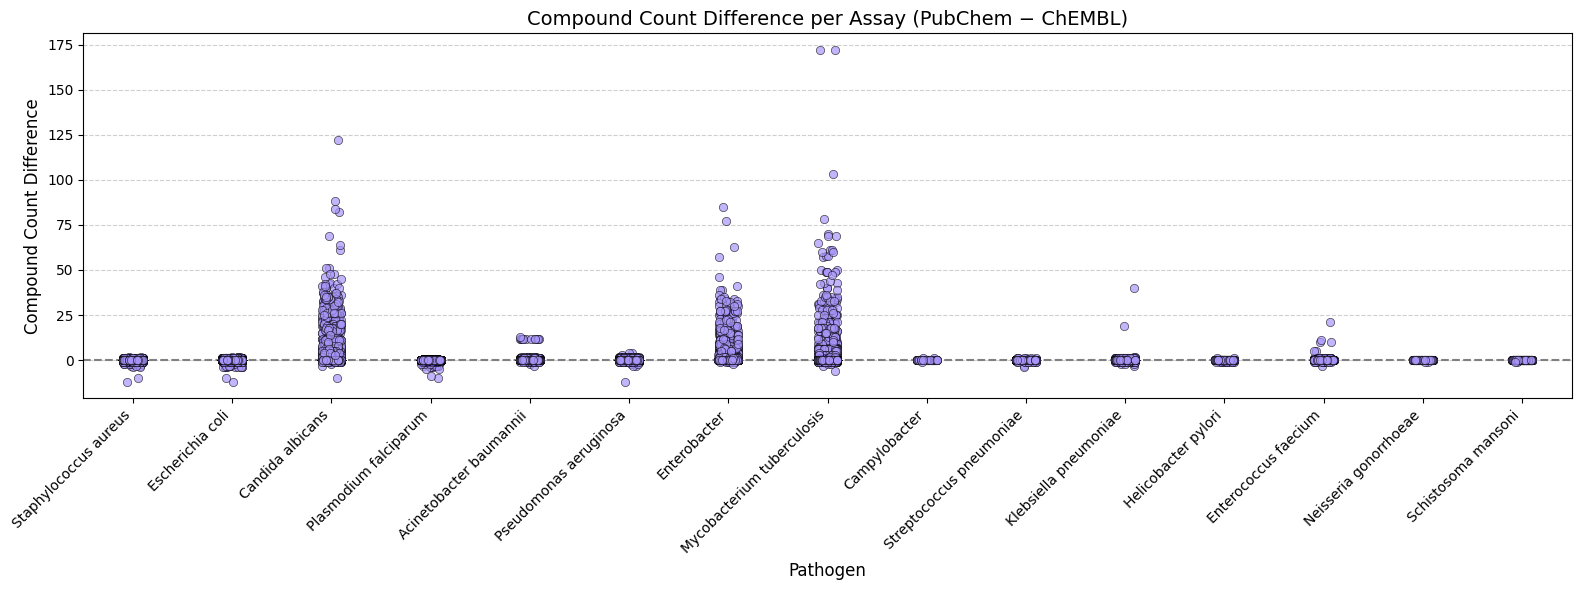

In [ ]:
# Reuse ChEMBL_id-filtered DataFrame
ChEMBL_id = summary_bioassays[
    summary_bioassays["ChEMBL_ID"].notna()
].dropna(
    subset=["compound_diff", "Pathogen", "PubChem_compounds", "ChEMBL_compounds"]
).copy()

# Plot: Compound Count Difference per Assay (only those with ChEMBL ID)
plt.figure(figsize=(16, 6))
sns.stripplot(
    data=ChEMBL_id,
    x="Pathogen",
    y="compound_diff",
    jitter=True,
    alpha=0.7,
    size=6,
    linewidth=0.5,
    edgecolor="black",
    color="#AA96FA"  # match with previous purple bar
)

plt.axhline(0, linestyle="--", color="gray")
plt.title("Compound Count Difference per Assay (PubChem − ChEMBL)", fontsize=14)
plt.ylabel("Compound Count Difference", fontsize=12)
plt.xlabel("Pathogen", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [48]:
# Filter rows where compound_diff is not zero and not null
df_check = summary_bioassays[
    (summary_bioassays["compound_diff"].notna()) &
    (summary_bioassays["compound_diff"] != 0)
]

# Check how many of those have ChEMBL_compounds == 0
count_zero_chembl = (df_check["ChEMBL_compounds"] == 0).sum()
total_diff = len(df_check)

print(f"Total rows with non-zero compound_diff: {total_diff}")
print(f"Rows where ChEMBL_compounds == 0: {count_zero_chembl}")
print(f"✅ All zero? {count_zero_chembl == total_diff}")

Total rows with non-zero compound_diff: 5630
Rows where ChEMBL_compounds == 0: 3459
✅ All zero? False


In [22]:
# Get top 10 assays with smallest absolute difference (more compunds in ChEMBL)
top_ChEMBL = ChEMBL_id.loc[
    ChEMBL_id["compound_diff"].abs().nsmallest(10).index,
    ["Pathogen", "PubChem_AID", "ChEMBL_ID", "PubChem_compounds", "ChEMBL_compounds", "compound_diff"]
]

# Clean index for display
top_ChEMBL = top_ChEMBL.reset_index(drop=True)

top_ChEMBL

,Pathogen,PubChem_AID,ChEMBL_ID,PubChem_compounds,ChEMBL_compounds,compound_diff
0,Staphylococcus aureus,2912,CHEMBL857900,1,1,0
1,Staphylococcus aureus,2913,CHEMBL615129,3,3,0
2,Staphylococcus aureus,2914,CHEMBL615130,14,14,0
3,Staphylococcus aureus,2915,CHEMBL615131,1,1,0
4,Escherichia coli,2936,CHEMBL615149,26,26,0
5,Escherichia coli,2940,CHEMBL615153,14,14,0
6,Escherichia coli,2941,CHEMBL615154,48,48,0
7,Candida albicans,2981,CHEMBL615203,1,1,0
8,Candida albicans,2982,CHEMBL615204,1,1,0
9,Candida albicans,3064,CHEMBL615377,29,29,0
